# Ricci Finance v12 — Bilingual Lecture Notebook  
# Ricci Finance v12 — 雙語講義筆記本

## Dynamic Ricci–capital networks, Gaussian HMM regimes, and market narratives  
## 動態 Ricci–資本網路、Gaussian HMM 狀態與市場敘事

This notebook is the teaching companion to `app_v12.py`. It exposes the full pipeline rather than hiding it behind the Streamlit interface.  
本筆記本是 `app_v12.py` 的教學版，逐步展示完整流程，而不是把計算隱藏在 Streamlit 介面後方。

### Learning objectives｜學習目標

1. Convert prices into rolling financial networks.｜將價格資料轉換為滾動金融網路。
2. Understand correlation distance and capital-adjusted distance.｜理解相關距離與資本調整距離。
3. Compute and interpret edgewise Ollivier–Ricci curvature.｜計算並解釋逐邊 Ollivier–Ricci 曲率。
4. Distinguish observed geometry from Ricci-flow regularization.｜區分觀測幾何與 Ricci flow 正則化。
5. Build graph-level time-series features from rolling frames.｜由滾動影格建立圖層級時間序列特徵。
6. Fit a Gaussian HMM and inspect posterior probabilities.｜配適 Gaussian HMM 並檢視後驗機率。
7. Generate evidence-based frame-to-frame narratives.｜根據量測變化產生逐影格敘事。
8. Visualize the sequence as a stable 3-D manifold animation.｜以固定佈局的 3-D 流形動畫呈現演化。

> Research and education only; this notebook does not predict or guarantee returns.  
> 僅供研究與教學；本筆記本不預測或保證投資報酬。


## 1. System architecture｜系統架構

```mermaid
flowchart TD
    A[Prices and volume<br/>價格與成交量] --> B[Returns and dollar volume<br/>報酬與成交金額]
    B --> C[Rolling windows<br/>滾動視窗]
    C --> D[Correlation and financial distance<br/>相關與金融距離]
    D --> E[Threshold or kNN graph<br/>門檻或 kNN 圖]
    B --> F[Capital mass and transport proxy<br/>資本質量與運輸代理量]
    E --> G[Capital-adjusted graph<br/>資本調整圖]
    F --> G
    G --> H[Ollivier–Ricci curvature<br/>Ollivier–Ricci 曲率]
    H --> I[Graph statistics by frame<br/>逐影格圖統計]
    I --> J[Gaussian HMM]
    J --> K[Posterior state probabilities<br/>狀態後驗機率]
    I --> L[Frame comparison<br/>影格比較]
    K --> L
    L --> M[Market narrative<br/>市場敘事]
    H --> N[Stable 3-D manifold<br/>固定佈局 3-D 流形]
    M --> N
```

Conceptual separation｜概念分工：

- **Ricci curvature** describes spatial network geometry.｜Ricci 曲率描述空間網路幾何。
- **Rolling frames** create temporal observations.｜滾動影格產生時間觀測。
- **HMM** infers persistent hidden regimes from observed features.｜HMM 由觀測特徵推論持續性的隱藏狀態。
- **Narrative generation** translates measured changes, not causal claims.｜敘事模組只翻譯量測變化，不宣稱因果。


## 2. Environment and imports｜環境與匯入

**Purpose:** load the v12 package used by the Streamlit application.  
**目的：**載入 Streamlit 應用程式使用的 v12 套件。

**Expected output:** imports succeed and package versions are shown.  
**預期輸出：**套件匯入成功，並顯示主要科學套件版本。


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import networkx as nx
import plotly
import matplotlib
from IPython.display import display

# Locate the repository root whether the notebook is run from root or a subfolder.
PROJECT_ROOT = Path.cwd().resolve()
for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (candidate / "ricci_finance").is_dir():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError(
        "Cannot find the 'ricci_finance' package. Run this notebook inside the v12 repository."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from ricci_finance import *


2026-07-18 17:58:32.197072: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/usr/lib/python3.14/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
import importlib.util

if importlib.util.find_spec("watermark") is not None:
    ip = get_ipython()
    ip.run_line_magic("load_ext", "watermark")
    ip.run_line_magic(
        "watermark",
        "-m -v -p pandas,yfinance,sklearn,GraphRicciCurvature,scipy,numpy,matplotlib,plotly",
    )
else:
    print("Optional package 'watermark' is not installed; version report skipped.")


Python implementation: CPython
Python version       : 3.14.2
IPython version      : 9.15.0

pandas             : 3.0.3
yfinance           : 1.5.1
sklearn            : 1.8.0
GraphRicciCurvature: 0.5.3.2
scipy              : 1.18.0
numpy              : 2.4.6
matplotlib         : 3.10.8
plotly             : 6.6.0

Compiler    : GCC 15.2.1 20251112
OS          : Linux
Release     : 6.1.161-1-MANJARO
Machine     : x86_64
Processor   : 
CPU cores   : 16
Architecture: 64bit



## 3. Download market data｜下載市場資料

**Purpose:** obtain close prices, volume, and dollar volume through the project's data loader.  
**目的：**透過專案資料載入器取得收盤價、成交量與成交金額。

This cell uses real market data when the loader is configured for `yfinance`; therefore the result depends on internet access, ticker availability, and listing dates.  
若資料載入器設定為 `yfinance`，本格使用真實市場資料；結果會受到網路、代號可用性與上市日期影響。


In [3]:
# from data.py
TICKERS = [
    "NVDA", "AMD", "MU", "ANET", "AAOI",
    "IONQ", "QBTS", "RGTI", "QNT", "SPCX", "CBRS",
]

close, volume, dollar_volume = download_market_data(TICKERS)

print("Close shape:", close.shape)
print("Volume shape:", volume.shape)
display(close.tail())


Close shape: (251, 11)
Volume shape: (251, 11)


Ticker,AAOI,AMD,ANET,CBRS,IONQ,MU,NVDA,QBTS,QNT,RGTI,SPCX
Date,,,,,,,,,,,
2026-07-13,111.879997,534.390015,181.149994,204.619995,38.880001,937.000000,203.529999,18.660000,64.089996,15.360000,139.139999
2026-07-14,125.449997,548.130005,182.570007,203.809998,39.290001,983.119995,211.800003,18.950001,66.629997,16.110001,136.080002
2026-07-15,109.089996,529.140015,171.919998,184.009995,37.509998,904.280029,212.500000,18.270000,60.509998,15.250000,135.270004
2026-07-16,100.239998,500.940002,168.559998,180.460007,35.099998,853.200012,207.399994,16.920000,56.520000,14.100000,131.110001
2026-07-17,102.410004,495.760010,168.610001,172.860001,34.779999,848.950012,202.809998,16.730000,56.070000,14.110000,123.989998


## 4. Validate data and calculate log returns｜驗證資料並計算對數報酬

For ticker $i$,

$$
r_i(t)=\log\!\left(\frac{P_i(t)}{P_i(t-1)}\right).
$$

### Why not correlate raw prices?｜為何不直接對價格計算相關？

Raw prices are usually non-stationary and may contain trends and changing variance. Correlation on price levels can therefore be dominated by common trends rather than synchronized returns.  
原始價格通常非定態，含有趨勢及變動變異數；直接對價格水準計算相關，可能只反映共同趨勢，而非同步報酬。

### Why logarithms?｜為何使用對數？

- Log returns are approximately symmetric: doubling gives $+\log 2$, while halving gives $-\log 2$.  
  對數報酬近似對稱：價格加倍為 $+\log 2$，減半為 $-\log 2$。
- They are additive through time:

$$
\log\frac{P_{t+2}}{P_t}
=
\log\frac{P_{t+1}}{P_t}
+
\log\frac{P_{t+2}}{P_{t+1}}.
$$

Log returns are not guaranteed to be normally distributed or stationary; they are simply more suitable than raw prices for this pipeline.  
對數報酬並不保證常態或定態，但通常比原始價格更適合本流程。


In [4]:
validation_warnings = validate_market_data(close, volume, minimum_rows=60)
print("Validation warnings:", validation_warnings or "none")

returns = prices_to_returns(close)
dollar_volume = dollar_volume.reindex(
    index=returns.index,
    columns=returns.columns,
)

print("Return shape:", returns.shape)
display(returns.tail())


Validation warnings: ['High missing-data ratio: CBRS, QNT, SPCX']
Return shape: (250, 11)


Ticker,AAOI,AMD,ANET,CBRS,IONQ,MU,NVDA,QBTS,QNT,RGTI,SPCX
Date,,,,,,,,,,,
2026-07-13,-0.069398,-0.043036,-0.031569,-0.049855,-0.097459,-0.044155,-0.035855,-0.073840,-0.094615,-0.074015,-0.043320
2026-07-14,0.114480,0.025387,0.007808,-0.003966,0.010490,0.048048,0.039829,0.015422,0.038867,0.047674,-0.022238
2026-07-15,-0.139734,-0.035259,-0.060104,-0.102198,-0.046363,-0.083592,0.003300,-0.036544,-0.096346,-0.054861,-0.005970
2026-07-16,-0.084606,-0.054767,-0.019737,-0.019481,-0.066406,-0.058145,-0.024293,-0.076764,-0.068214,-0.078405,-0.031236
2026-07-17,0.021417,-0.010394,0.000297,-0.043027,-0.009159,-0.004994,-0.022380,-0.011293,-0.007994,0.000709,-0.055836


---


## 5. Inspect market features｜檢視市場特徵

The feature layer provides economic context in addition to graph geometry.  
特徵層在圖幾何之外提供經濟背景。


In [5]:
# from feature.py

market_features = compute_market_features(
    close=close,
    volume=volume,
    window=60,
)

print("Available feature tables:", list(market_features))
display(market_features["volatility"].tail())

Available feature tables: ['returns', 'volatility', 'momentum', 'drawdown', 'dollar_volume', 'relative_volume']


Ticker,AAOI,AMD,ANET,CBRS,IONQ,MU,NVDA,QBTS,QNT,RGTI,SPCX
Date,,,,,,,,,,,
2026-07-13,1.405010,0.849620,0.639610,1.303327,0.947144,1.038039,0.411066,1.118639,1.164590,1.121482,1.221111
2026-07-14,1.410335,0.839925,0.634347,1.286621,0.944808,1.040440,0.418871,1.116807,1.146699,1.125598,1.189668
2026-07-15,1.437044,0.845069,0.645853,1.290586,0.946507,1.058498,0.417645,1.118817,1.165302,1.129621,1.159575
2026-07-16,1.444368,0.854421,0.646422,1.274855,0.949170,1.066791,0.420808,1.129011,1.161728,1.139753,1.134294
2026-07-17,1.437271,0.853924,0.642244,1.261687,0.945938,1.067137,0.422787,1.122696,1.140915,1.130987,1.118859


In [6]:
list(market_features.keys())

['returns',
 'volatility',
 'momentum',
 'drawdown',
 'dollar_volume',
 'relative_volume']

### Feature definitions｜特徵定義

1. **Annualized volatility｜年化波動率**
   $$\sigma_i(t)=\operatorname{Std}(r_i)_{t-w+1:t}\sqrt{252}.$$
   This is standard deviation, not variance.｜這是標準差，不是變異數。

2. **Momentum｜動能**
   $$M_i(t)=\frac{P_i(t)}{P_i(t-w)}-1.$$

3. **Drawdown｜回撤**
   $$DD_i(t)=\frac{P_i(t)}{\max_{u\in[t-w+1,t]}P_i(u)}-1.$$
   It measures decline from the rolling peak; it is not the maximum profit.  
   它衡量相對於視窗高點的跌幅，不是最大獲利。

4. **Dollar volume｜成交金額**
   $$DV_i(t)=P_i(t)V_i(t).$$

5. **Relative volume｜相對成交量**
   $$RV_i(t)=\frac{V_i(t)}{\frac1w\sum_{k=0}^{w-1}V_i(t-k)}.$$


## 6. Correlation and financial distance｜相關與金融距離

Convert Pearson correlation to a non-negative distance:

$$
d_{ij}^{\mathrm{corr}}=\sqrt{2(1-\rho_{ij})}.
$$

| Correlation｜相關 | Distance｜距離 | Interpretation｜解釋 |
|---:|---:|---|
| $\rho\approx1$ | $d\approx0$ | very similar returns｜報酬非常相似 |
| $\rho\approx0$ | $d\approx\sqrt2$ | intermediate｜中等 |
| $\rho\approx-1$ | $d\approx2$ | opposite movement｜反向移動 |

### Why transform correlation?｜為何轉換相關？

Ollivier–Ricci curvature and optimal transport require a non-negative ground distance. Correlation is a similarity in $[-1,1]$, not an edge length.  
Ollivier–Ricci 曲率與最佳運輸需要非負的基礎距離；相關係數是 $[-1,1]$ 的相似度，而不是邊長。

For an edge $(i,j)$,

$$
\kappa(i,j)=1-\frac{W_1(m_i,m_j)}{d(i,j)}.
$$

A graph builder must avoid zero-length edges or regularize them numerically.  
建圖時必須避免零長度邊，或以數值方式加以正則化。


In [7]:
WINDOW_SIZE = 60
window_returns = returns.iloc[-WINDOW_SIZE:]

corr = window_returns.corr(min_periods=20)
dist = financial_distance_from_corr(corr)

display(corr.round(3))
display(dist.round(3))

Ticker,AAOI,AMD,ANET,CBRS,IONQ,MU,NVDA,QBTS,QNT,RGTI,SPCX
Ticker,,,,,,,,,,,
AAOI,1.000,0.402,0.378,0.357,0.529,0.424,0.332,0.417,0.244,0.478,0.133
AMD,0.402,1.000,0.296,0.165,0.571,0.664,0.483,0.461,0.557,0.490,0.197
ANET,0.378,0.296,1.000,0.123,0.267,0.419,0.231,0.251,0.295,0.315,0.139
CBRS,0.357,0.165,0.123,1.000,0.408,0.111,0.206,0.293,0.317,0.238,0.213
IONQ,0.529,0.571,0.267,0.408,1.000,0.504,0.338,0.861,0.497,0.862,0.199
MU,0.424,0.664,0.419,0.111,0.504,1.000,0.428,0.357,0.373,0.365,0.073
NVDA,0.332,0.483,0.231,0.206,0.338,0.428,1.000,0.229,0.298,0.321,0.209
QBTS,0.417,0.461,0.251,0.293,0.861,0.357,0.229,1.000,0.600,0.950,0.379
QNT,0.244,0.557,0.295,0.317,0.497,0.373,0.298,0.600,1.000,0.587,0.090


Ticker,AAOI,AMD,ANET,CBRS,IONQ,MU,NVDA,QBTS,QNT,RGTI,SPCX
Ticker,,,,,,,,,,,
AAOI,0.000,1.093,1.115,1.134,0.971,1.074,1.156,1.080,1.230,1.021,1.317
AMD,1.093,0.000,1.186,1.292,0.926,0.819,1.016,1.039,0.941,1.010,1.267
ANET,1.115,1.186,0.000,1.324,1.211,1.078,1.240,1.224,1.187,1.170,1.312
CBRS,1.134,1.292,1.324,0.000,1.088,1.333,1.260,1.189,1.169,1.235,1.255
IONQ,0.971,0.926,1.211,1.088,0.000,0.996,1.150,0.527,1.003,0.526,1.266
MU,1.074,0.819,1.078,1.333,0.996,0.000,1.070,1.134,1.120,1.127,1.362
NVDA,1.156,1.016,1.240,1.260,1.150,1.070,0.000,1.241,1.185,1.165,1.257
QBTS,1.080,1.039,1.224,1.189,0.527,1.134,1.241,0.000,0.895,0.317,1.114
QNT,1.230,0.941,1.187,1.169,1.003,1.120,1.185,0.895,0.000,0.909,1.349


## 7. Build the financial graph｜建立金融圖

Each node is a ticker. Edges are selected using `knn+bridges`:  
每個節點代表一個股票代號，使用 `knn+bridges` 選邊：

- k-nearest-neighbor edges preserve local relationships.｜kNN 邊保留局部關係。
- Additional bridge edges preserve selected cross-cluster links.｜額外橋接邊保留部分跨群關係。
- Pair overlap and confidence are stored as edge attributes.｜共同觀測數與信心值存於邊屬性。


In [8]:
G0, corr_frame, dist_frame = build_graph_from_window(
    window_returns,
    graph_mode="knn+bridges",
    k_neighbors=3,
    min_corr=0.05,
    max_bridges=3,
    min_pair_obs=20,
)

print("Nodes:", G0.number_of_nodes())
print("Edges:", G0.number_of_edges())
display(summarize_edges(G0))

Nodes: 11
Edges: 27


,u,v,distance,raw_distance,correlation,ricciCurvature,edge_capital_flow,capital_similarity,overlap_n,confidence,edge_source
22,QBTS,RGTI,0.317459,NaN,0.949610,0.0,0.0,NaN,60,1.000000,graph
16,IONQ,RGTI,0.525546,NaN,0.861901,0.0,0.0,NaN,60,1.000000,graph
17,IONQ,QBTS,0.527089,NaN,0.861088,0.0,0.0,NaN,60,1.000000,graph
5,AMD,MU,0.819471,NaN,0.664234,0.0,0.0,NaN,60,1.000000,graph
23,QBTS,QNT,0.894777,NaN,0.599687,0.0,0.0,NaN,29,0.483333,graph
25,QNT,RGTI,0.909375,NaN,0.586518,0.0,0.0,NaN,29,0.483333,graph
6,AMD,IONQ,0.925868,NaN,0.571385,0.0,0.0,NaN,60,1.000000,graph
7,AMD,QNT,0.940856,NaN,0.557395,0.0,0.0,NaN,29,0.483333,graph
0,AAOI,IONQ,0.970824,NaN,0.528751,0.0,0.0,NaN,60,1.000000,graph
18,IONQ,MU,0.996268,NaN,0.503725,0.0,0.0,NaN,60,1.000000,graph


## 8. Add capital mass and transport proxies｜加入資本質量與運輸代理量

Correlation answers **whether two stocks move together**, but not whether the relationship involves highly traded or thinly traded stocks.  
相關係數回答「兩檔股票是否同步」，但不能區分其交易規模。

For each node, use median dollar volume in the current window as a robust capital-mass proxy:

$$
M_i=\operatorname{median}_{t\in\mathcal W}\bigl(P_i(t)V_i(t)\bigr).
$$

A symmetric edge-activity proxy is

$$
F_{ij}=\sqrt{M_iM_j}\max(\rho_{ij},0).
$$

This is **not observed cash flow from $i$ to $j$**. It is an undirected activity/capacity proxy. Negative correlation is clipped to zero by modeling choice.  
這不是從 $i$ 流向 $j$ 的實際資金流，而是無方向的活動／容量代理量；負相關被截為零是模型選擇。

Capital-scale similarity is

$$
s_{ij}=1-\frac{|M_i-M_j|}{M_i+M_j},\qquad 0\le s_{ij}\le1,
$$

with an explicit zero-denominator safeguard in code. The capital-adjusted distance is

$$
d_{ij}^{\mathrm{eff}}
=\frac{d_{ij}^{\mathrm{corr}}}{1+\alpha_c s_{ij}}.
$$

Thus similar capital scales shorten the effective edge. This is a designed economic deformation of the correlation manifold, not a uniquely derived law.  
因此，資本規模越相似，等效邊長越短；這是對相關流形的人為經濟變形，不是唯一必然的定律。


In [9]:
capital_window = dollar_volume.reindex(
    index=window_returns.index,
    columns=window_returns.columns,
)

G_capital = attach_capital_attributes(
    G0,
    capital_window,
    capital_alpha=0.35,
    use_capital_weighting=True,
)

display(node_capital_table(G_capital))
display(capital_flow_table(G_capital).head(10))

,ticker,status,valid_obs,capital_mass,capital_share,degree
5,MU,active,60,4.616903e+10,0.409106,5
6,NVDA,active,60,3.158247e+10,0.279854,3
1,AMD,active,60,1.499136e+10,0.132839,6
10,SPCX,active,23,1.294735e+10,0.114727,3
0,AAOI,active,60,1.837051e+09,0.016278,5
2,ANET,active,60,1.405076e+09,0.012450,3
4,IONQ,active,60,1.342949e+09,0.011900,8
3,CBRS,active,43,1.258686e+09,0.011153,4
7,QBTS,active,60,5.693502e+08,0.005045,5
9,RGTI,active,60,5.195840e+08,0.004604,7


,u,v,edge_capital_flow,edge_flow_share,capital_similarity,effective_distance,raw_corr_distance,correlation,ricciCurvature,confidence
5,AMD,MU,1.747499e+10,0.240270,0.344651,0.731260,0.819471,0.664234,0.0,1.0
21,MU,NVDA,1.633894e+10,0.224650,0.693393,0.860786,1.069688,0.427883,0.0,1.0
8,AMD,NVDA,1.051764e+10,0.144611,0.497049,0.865867,1.016499,0.483364,0.0,1.0
18,IONQ,MU,3.966415e+09,0.054536,0.057763,0.976526,0.996268,0.503725,0.0,1.0
2,AAOI,MU,3.900762e+09,0.053633,0.068149,1.048710,1.073724,0.423559,0.0,1.0
11,ANET,MU,3.378102e+09,0.046447,0.059069,1.055746,1.077573,0.419418,0.0,1.0
6,AMD,IONQ,2.563769e+09,0.035250,0.167599,0.874566,0.925868,0.571385,0.0,1.0
19,IONQ,NVDA,2.203297e+09,0.030294,0.083305,1.117788,1.150379,0.338314,0.0,1.0
9,AMD,RGTI,1.366781e+09,0.018792,0.117383,0.970358,1.010225,0.489723,0.0,1.0
10,AMD,QBTS,1.345709e+09,0.018503,0.120418,0.996631,1.038636,0.460618,0.0,1.0


### $G_0$ and $G_{\mathrm{capital}}$｜$G_0$ 與 $G_{\mathrm{capital}}$

- $G_0$ uses $d^{\mathrm{corr}}$ and represents statistical similarity.  
  $G_0$ 使用 $d^{\mathrm{corr}}$，代表統計相似性。
- $G_{\mathrm{capital}}$ uses $d^{\mathrm{eff}}$ and adds capital-scale compatibility.  
  $G_{\mathrm{capital}}$ 使用 $d^{\mathrm{eff}}$，加入資本規模相容性。

The node set and selected edge set may stay the same while edge lengths and attributes change.  
節點與選定邊集合可保持相同，但邊長與屬性會改變。


## 9. Compute Ollivier–Ricci curvature｜計算 Ollivier–Ricci 曲率

### Why introduce curvature?｜為何引入曲率？

Correlation describes one pair. Curvature compares the neighborhoods surrounding that pair, so it can distinguish an internal cluster edge from a fragile bridge even when the direct correlation is identical.  
相關只描述一對節點；曲率比較該邊兩端的鄰域，因此即使直接相關相同，也能區分群內邊與脆弱橋接邊。

For each edge $(i,j)$,

$$
\kappa(i,j)=1-\frac{W_1(m_i,m_j)}{d(i,j)}.
$$

The Wasserstein-1 distance is

$$
W_1(\mu,\nu)
=\min_{\pi\in\Pi(\mu,\nu)}
\sum_{x,y}d(x,y)\pi(x,y),
$$

where $\pi$ is a transport plan with marginals $\mu$ and $\nu$.

### Correct three-node example｜正確的三節點例子

```text
A ----- B ----- C      each edge length = 1
```

Let

$$m_1=(0.5,0.5,0),\qquad m_2=(0,0.5,0.5).$$

The $0.5$ mass at $B$ already matches. The remaining $0.5$ must move from $A$ to $C$, a distance of $2$:

$$W_1(m_1,m_2)=0.5\times2=1.$$

If $d(i,j)=1$, then $\kappa(i,j)=1-1/1=0$. The earlier value $0.5$ would incorrectly move mass only one edge and fail to satisfy the target distribution.  
若 $d(i,j)=1$，則 $\kappa(i,j)=0$。先前的 $0.5$ 結果只移動一條邊，未真正到達目標分布，因此不正確。

Curvature is first computed **per edge**. A graph-level summary may then use

$$
\bar\kappa=\frac1{|E|}\sum_{(i,j)\in E}\kappa(i,j),
$$

but $\bar\kappa$ is not the definition of edge curvature.  
曲率先逐邊計算；圖層級平均只是後續摘要，不是邊曲率的定義。

- Negative: stretched or bridge-like.｜負值：拉伸或橋接型。
- Near zero: locally neutral.｜接近零：局部中性。
- Positive: cohesive/redundant neighborhoods.｜正值：鄰域凝聚且具冗餘。


In [10]:
G_ricci = compute_ricci_curvature(
    G_capital,
    alpha=0.5,
    method="OTD",
    proc=1,
)

 

edge_table = summarize_edges(G_ricci)
display(edge_table.sort_values("ricciCurvature"))

,u,v,distance,raw_distance,correlation,ricciCurvature,edge_capital_flow,capital_similarity,overlap_n,confidence,edge_source
22,QBTS,RGTI,0.236702,0.317459,0.949610,0.004124,5.164911e+08,0.974795,60,1.000000,graph
17,IONQ,QBTS,0.421176,0.527089,0.861088,0.066525,7.529518e+08,0.718489,60,1.000000,graph
12,ANET,RGTI,0.944137,1.170459,0.315013,0.190162,2.691575e+08,0.684895,60,1.000000,graph
19,IONQ,NVDA,1.117788,1.150379,0.338314,0.197486,2.203297e+09,0.083305,60,1.000000,graph
16,IONQ,RGTI,0.422080,0.525546,0.861901,0.205750,7.199708e+08,0.700380,60,1.000000,graph
18,IONQ,MU,0.976526,0.996268,0.503725,0.208458,3.966415e+09,0.057763,60,1.000000,graph
4,AAOI,CBRS,0.881028,1.134380,0.356591,0.215561,5.422383e+08,0.821609,43,0.716667,graph
13,CBRS,IONQ,0.812534,1.088200,0.407910,0.217422,5.303379e+08,0.969337,43,0.716667,graph
2,AAOI,MU,1.048710,1.073724,0.423559,0.236319,3.900762e+09,0.068149,60,1.000000,graph
0,AAOI,IONQ,0.748711,0.970824,0.528751,0.237020,8.305030e+08,0.847599,60,1.000000,graph


## 10. View one 3-D Ricci–capital manifold｜檢視單一 3-D Ricci–資本流形

Visual encoding｜視覺編碼：

- node size: capital-mass proxy｜節點大小：資本質量代理量
- node color: connected component｜節點顏色：連通分量
- edge width: activity/transport proxy｜邊寬：活動／運輸代理量
- edge color: edge Ricci curvature｜邊色：逐邊 Ricci 曲率
- z-axis: selected stress or capital attribute｜z 軸：選定的壓力或資本屬性

The 3-D layout is a visualization embedding, not proof that the financial network is a smooth physical manifold.  
3-D 佈局是視覺嵌入，不代表金融網路已被證明為光滑物理流形。


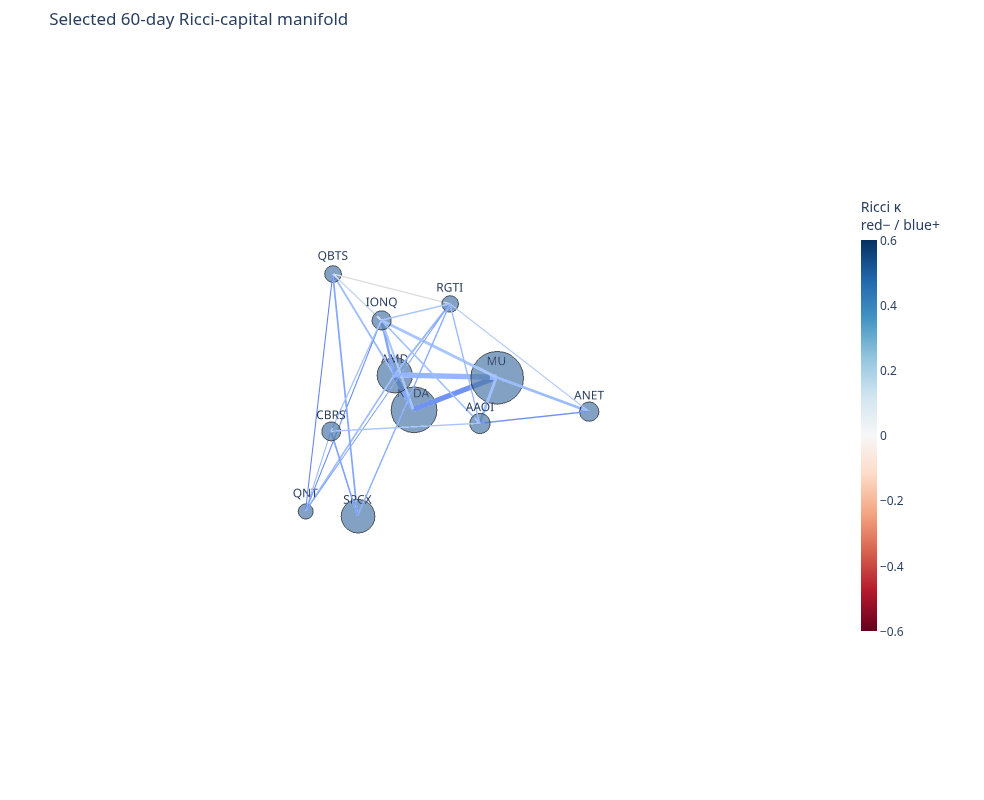

In [11]:
positions_3d = compute_stable_layout_3d(
    G_ricci,
    seed=42,
)

fig_single = visualize_network_3d(
    G_ricci,
    positions_3d=positions_3d,
    title="Selected 60-day Ricci-capital manifold",
    node_cluster=compute_components(G_ricci),
    z_mode="ricci_stress",
)
fig_single.show()

## 11. Ricci flow: geometric regularization, not forecasting｜Ricci flow：幾何正則化，而非預測

| Graph｜圖 | Represents｜代表 | Main question｜主要問題 |
|---|---|---|
| $G_0$ | statistical similarity｜統計相似性 | Which stocks move together?｜哪些股票同步？ |
| $G_{\mathrm{capital}}$ | similarity plus capital compatibility｜相似性加資本相容性 | Which links remain close after capital deformation?｜經資本變形後哪些連結仍接近？ |
| $G_{\mathrm{flowed}}$ | Ricci-flow-regularized geometry｜Ricci flow 正則化幾何 | What geometry results from iterative curvature smoothing?｜迭代曲率平滑後得到何種幾何？ |

A simplified discrete update is

$$
d_{ij}^{(t+1)}=d_{ij}^{(t)}\bigl(1-\eta\kappa_{ij}^{(t)}\bigr).
$$

Under this sign convention, positive-curvature edges contract and negative-curvature edges expand. Implementations may also normalize lengths to control scale.  
在此符號慣例下，正曲率邊收縮、負曲率邊擴張；實作可能另做長度正規化以控制尺度。

The output is a **model-dependent regularized geometry**, not the market's true intrinsic geometry and not a future state forecast.  
輸出是依模型而定的正則化幾何，不應稱為市場「真正」內在幾何，也不是未來狀態預測。


,iteration,avg_weight,avg_ricci,ricci_min,ricci_max
0,0,0.858294,0.268231,0.004124,0.447818
1,1,0.858294,0.266700,0.040243,0.448981
2,2,0.858294,0.264562,0.070495,0.449825
3,3,0.858294,0.261954,0.096158,0.450290
4,4,0.858294,0.259036,0.118579,0.450338
5,5,0.858294,0.255803,0.138222,0.449920
6,6,0.858294,0.252396,0.153982,0.449015
7,7,0.858294,0.248906,0.144941,0.447431
8,8,0.858294,0.245438,0.136038,0.445156


,u,v,before_weight,after_weight,delta_weight,before_ricci,after_ricci,delta_ricci
0,AAOI,ANET,0.855480,0.649359,-0.206121,0.398426,0.359758,-0.038668
1,AAOI,CBRS,0.881028,1.017419,0.136391,0.215561,0.156628,-0.058933
2,AAOI,IONQ,0.748711,0.828556,0.079845,0.237020,0.181151,-0.055869
3,AAOI,MU,1.048710,1.180008,0.131298,0.236319,0.163864,-0.072456
4,AAOI,RGTI,0.845692,0.880318,0.034626,0.268546,0.205458,-0.063088
5,AMD,IONQ,0.874566,0.798017,-0.076549,0.341244,0.237270,-0.103974
6,AMD,MU,0.731260,0.742454,0.011194,0.268386,0.223428,-0.044958
7,AMD,NVDA,0.865867,0.819938,-0.045929,0.331279,0.227074,-0.104205
8,AMD,QBTS,0.996631,1.098000,0.101369,0.244106,0.179414,-0.064692
9,AMD,QNT,0.909117,0.995401,0.086284,0.244011,0.182055,-0.061956


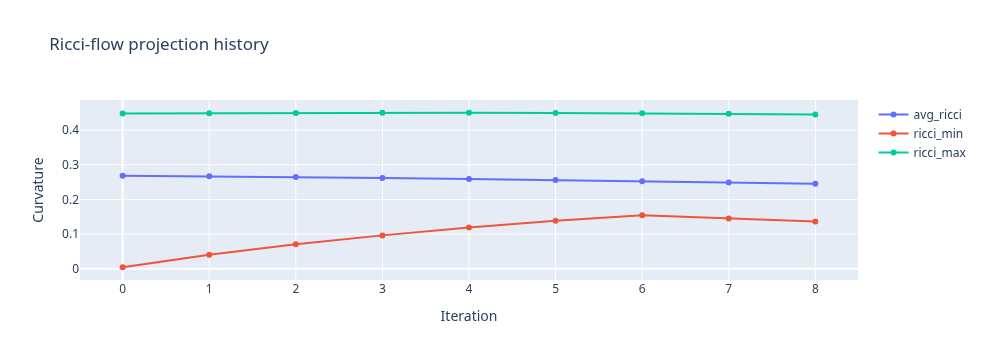

In [12]:
G_flowed, flow_history = run_ricci_flow(
    G_ricci,
    iterations=8,
    step_size=0.25,
    alpha=0.5,
    method="OTD",
    proc=1,
)

display(flow_history)
display(compare_before_after_flow(G_ricci, G_flowed).head(10))
plot_ricci_flow_history(flow_history).show()

## 12. Build rolling frames｜建立滾動影格

A rolling frame repeats graph construction over a moving window.  
每個滾動影格都在移動視窗上重建整套圖。

```text
Frame 1: days 1–60
Frame 2: days 6–65
Frame 3: days 11–70
```

Each frame stores dates, graph objects, distances, components, capital attributes, curvature, and graph-level statistics.  
每個影格保存日期、圖物件、距離、連通分量、資本屬性、曲率與圖層級統計。


In [13]:
frames, starts = build_rolling_frames(
    returns=returns,
    window_size=60,
    step=5,
    max_frames=30,
    graph_mode="knn+bridges",
    k_neighbors=3,
    min_corr=0.05,
    max_bridges=3,
    min_pair_obs=20,
    alpha=0.5,
    method="OTD",
    proc=1,
    dollar_volume=dollar_volume,
    use_capital_weighting=True,
    capital_alpha=0.35,
)

print("Frames:", len(frames))
print("First frame date:", frames[0].stats.end_date)
print("Last frame date:", frames[-1].stats.end_date)

Frames: 30
First frame date: 2025-10-13 00:00:00
Last frame date: 2026-07-17 00:00:00


## 13. Graph-level time series｜圖層級時間序列

The HMM does not consume every edge directly. `rolling_feature_table(frames)` converts each frame into one observation vector.  
HMM 不直接吃入每一條邊；`rolling_feature_table(frames)` 將每個影格轉成一個觀測向量。

Therefore `feature_df` is the principal **HMM input feature table**, whereas the later `hmm_df` is primarily an **HMM output table** containing dates, inferred states, labels, and probabilities.  
因此 `feature_df` 才是主要的 **HMM 輸入特徵表**；後面的 `hmm_df` 主要是包含日期、推論狀態、標籤與機率的 **HMM 輸出表**。


Feature columns｜特徵欄位： ['date', 'avg_ricci', 'ricci_std', 'ricci_min', 'ricci_max', 'negative_edge_ratio', 'clusters', 'largest_component', 'largest_component_ratio', 'nodes', 'edges', 'density', 'component_entropy', 'edge_stability', 'total_node_capital', 'total_edge_capital_flow', 'avg_edge_capital_flow', 'max_node_capital_share', 'hmm_state', 'regime_name', 'mean_ricci', 'mean_return', 'volatility', 'delta2']
Compatibility aliases｜相容別名： {'mean_ricci': 'avg_ricci', 'mean_return': 'derived from rolling returns', 'volatility': 'derived annualized market volatility', 'delta2': 'neutral compatibility placeholder; not used as evidence'}


,date,avg_ricci,ricci_std,ricci_min,ricci_max,negative_edge_ratio,clusters,largest_component,largest_component_ratio,nodes,...,total_node_capital,total_edge_capital_flow,avg_edge_capital_flow,max_node_capital_share,hmm_state,regime_name,mean_ricci,mean_return,volatility,delta2
0,2025-10-13 00:00:00,0.340581,0.097902,0.132115,0.535039,0.0,4,8,0.727273,11,...,4.278340e+10,1.921615e+10,1.067564e+09,0.658118,-1,not computed,0.340581,0.007753,0.468808,0.0
1,2025-10-20 00:00:00,0.319599,0.148126,0.078294,0.547104,0.0,4,8,0.727273,11,...,4.554217e+10,1.926777e+10,1.070431e+09,0.642997,-1,not computed,0.319599,0.007245,0.472361,0.0
2,2025-10-27 00:00:00,0.338051,0.129387,0.135249,0.541674,0.0,4,8,0.727273,11,...,4.723341e+10,2.101751e+10,1.167639e+09,0.615605,-1,not computed,0.338051,0.009155,0.501799,0.0
3,2025-11-03 00:00:00,0.366739,0.157503,0.023576,0.574852,0.0,4,8,0.727273,11,...,5.018150e+10,2.251632e+10,1.250907e+09,0.611951,-1,not computed,0.366739,0.007701,0.513352,0.0
4,2025-11-17 00:00:00,0.338127,0.164260,0.135215,0.638332,0.0,4,8,0.727273,11,...,5.452181e+10,2.711459e+10,1.594976e+09,0.616686,-1,not computed,0.338127,0.004218,0.559029,0.0


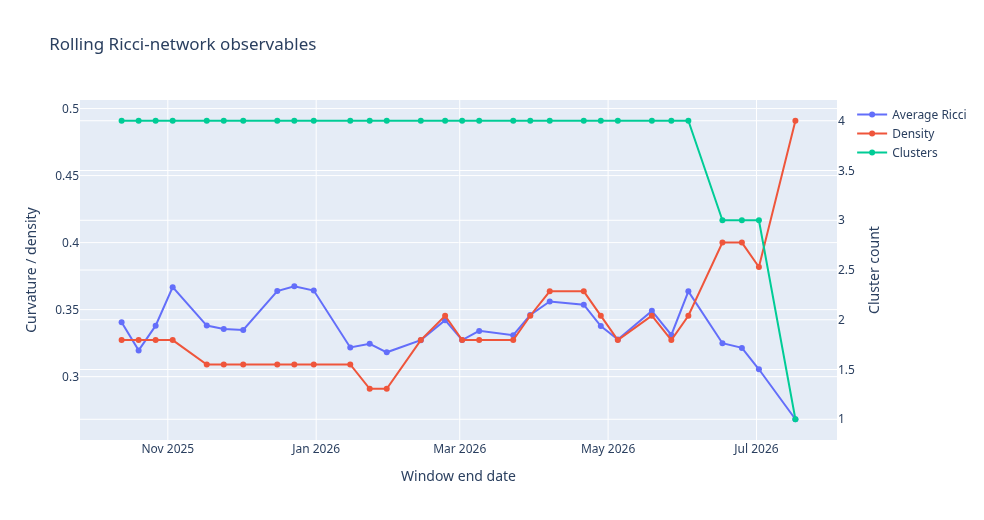

In [14]:

# Compatibility layer for v12 feature-column naming differences.
# v12 特徵欄位命名差異相容層。
#
# Some helper.py versions expect:
#   mean_return, volatility, mean_ricci, delta2
# while rolling_feature_table() may emit different names. We create only
# the missing aliases from available columns and never overwrite real data.

feature_df = rolling_feature_table(frames).copy()

def _first_existing_column(df, candidates):
    return next((name for name in candidates if name in df.columns), None)

feature_alias_candidates = {
    "mean_return": [
        "mean_return", "market_return", "avg_return", "return_mean",
        "mean_ret", "forward_return", "realized_return"
    ],
    "volatility": [
        "volatility", "market_volatility", "avg_volatility",
        "mean_volatility", "return_std", "vol"
    ],
    "mean_ricci": [
        "mean_ricci", "mean_curvature", "avg_ricci",
        "ricci_mean", "kappa_mean", "mean_kappa"
    ],
    "delta2": [
        "delta2", "delta_2", "Delta2", "flow_distance",
        "ricci_flow_distance", "geometric_stress",
        "distance_to_flow", "graph_delta"
    ],
}

created_aliases = {}
for target, candidates in feature_alias_candidates.items():
    if target in feature_df.columns:
        continue
    source = _first_existing_column(feature_df, candidates)
    if source is not None:
        feature_df[target] = pd.to_numeric(feature_df[source], errors="coerce")
        created_aliases[target] = source

# Derive return and volatility from the same rolling windows when absent.
frame_dates = pd.to_datetime([frame.stats.end_date for frame in frames])

if "mean_return" not in feature_df.columns:
    derived_mean_return = []
    for start in starts[:len(feature_df)]:
        window = returns.iloc[start:start + 60]
        derived_mean_return.append(
            float(window.mean(axis=1, skipna=True).mean())
            if not window.empty else np.nan
        )
    feature_df["mean_return"] = derived_mean_return
    created_aliases["mean_return"] = "derived from rolling returns"

if "volatility" not in feature_df.columns:
    derived_volatility = []
    for start in starts[:len(feature_df)]:
        window = returns.iloc[start:start + 60]
        market_series = window.mean(axis=1, skipna=True)
        derived_volatility.append(
            float(market_series.std(ddof=1) * np.sqrt(252))
            if market_series.notna().sum() > 1 else np.nan
        )
    feature_df["volatility"] = derived_volatility
    created_aliases["volatility"] = "derived annualized market volatility"

# Curvature alias from likely graph-stat columns.
if "mean_ricci" not in feature_df.columns:
    curvature_source = _first_existing_column(
        feature_df,
        [c for c in feature_df.columns if "ricci" in c.lower() or "curvature" in c.lower()]
    )
    if curvature_source is not None:
        feature_df["mean_ricci"] = pd.to_numeric(
            feature_df[curvature_source], errors="coerce"
        )
        created_aliases["mean_ricci"] = curvature_source

# delta2 is optional for animation and HMM. If unavailable, use a neutral
# zero-valued placeholder only for legacy helper compatibility.
if "delta2" not in feature_df.columns:
    feature_df["delta2"] = 0.0
    created_aliases["delta2"] = (
        "neutral compatibility placeholder; not used as evidence"
    )

print("Feature columns｜特徵欄位：", list(feature_df.columns))
print("Compatibility aliases｜相容別名：", created_aliases)

display(feature_df.head())
plot_rolling_features(feature_df).show()


## 14. Gaussian Hidden Markov Model｜Gaussian 隱藏馬可夫模型

Let $S_t$ be the hidden regime and $Y_t$ the observed graph-feature vector:

$$P(S_t\mid S_{t-1}),\qquad P(Y_t\mid S_t).$$

The HMM separates noisy observations from a more persistent latent state. It does **not** prove that the state is economically real, nor does it identify hidden “noise”; it infers a probabilistic regime under the model assumptions.  
HMM 將雜訊化觀測與較持續的潛在狀態分開；它不證明該狀態具有客觀經濟實體，也不是在辨識某種「隱藏噪音」，而是在模型假設下推論機率狀態。

v12 standardizes selected graph features, fits a diagonal-covariance Gaussian HMM, estimates the most likely state sequence, and computes posterior probabilities.  
v12 將選定圖特徵標準化，配適對角共變異 Gaussian HMM，估計最可能狀態序列並計算後驗機率。

### Input versus output｜輸入與輸出

- `feature_df`: observed graph-level features supplied to the model.｜輸入模型的圖層級觀測特徵。
- `hmm_state`: integer state ID; the number itself has no fixed meaning.｜整數狀態編號，本身無固定意義。
- `regime_name`: post-hoc human-readable label based on state statistics.｜根據狀態統計事後命名的可讀標籤。
- `state_probability`: posterior probability of the selected state.｜所選狀態的後驗機率。
- `state_probability_k`: posterior probability for every state $k$.｜每個狀態 $k$ 的後驗機率。

Avoid fixed claims such as “positive Ricci always means rotation.” A regime label must be assigned from the complete state profile—returns, volatility, curvature, fragmentation, stability, and capital variables—not from one feature alone.  
避免宣稱「正 Ricci 必然代表輪動」；狀態名稱必須由完整特徵輪廓決定，不能只看單一特徵。


Regime labels: {1: 'stress / fragmentation', 2: 'transition / rotation'}


,date,avg_ricci,ricci_std,ricci_min,ricci_max,negative_edge_ratio,clusters,largest_component,largest_component_ratio,nodes,...,total_edge_capital_flow,avg_edge_capital_flow,max_node_capital_share,hmm_state,regime_name,next_5d_market_return,state_probability_0,state_probability_1,state_probability_2,state_probability
25,2026-06-03 00:00:00,0.363633,0.079325,0.193902,0.583559,0.000000,4,8,0.727273,11,...,3.926048e+10,2.066341e+09,0.438613,2,transition / rotation,-0.127174,1.840309e-56,1.244681e-15,1.0,1.0
26,2026-06-17 00:00:00,0.324945,0.099650,0.154066,0.543491,0.000000,3,9,0.818182,11,...,5.903168e+10,2.683258e+09,0.355422,1,stress / fragmentation,-0.053596,6.278133e-53,1.000000e+00,0.0,1.0
27,2026-06-25 00:00:00,0.321462,0.090791,0.020408,0.498691,0.000000,3,9,0.818182,11,...,6.178905e+10,2.808593e+09,0.299459,1,stress / fragmentation,-0.014129,1.354697e-47,1.000000e+00,0.0,1.0
28,2026-07-02 00:00:00,0.305526,0.118714,-0.105675,0.534906,0.047619,3,9,0.818182,11,...,6.738540e+10,3.208829e+09,0.359726,1,stress / fragmentation,-0.013080,4.840801e-46,1.000000e+00,0.0,1.0
29,2026-07-17 00:00:00,0.268231,0.095979,0.004124,0.447818,0.000000,1,11,1.000000,11,...,7.273052e+10,2.693723e+09,0.409106,1,stress / fragmentation,NaN,6.648911e-44,1.000000e+00,0.0,1.0


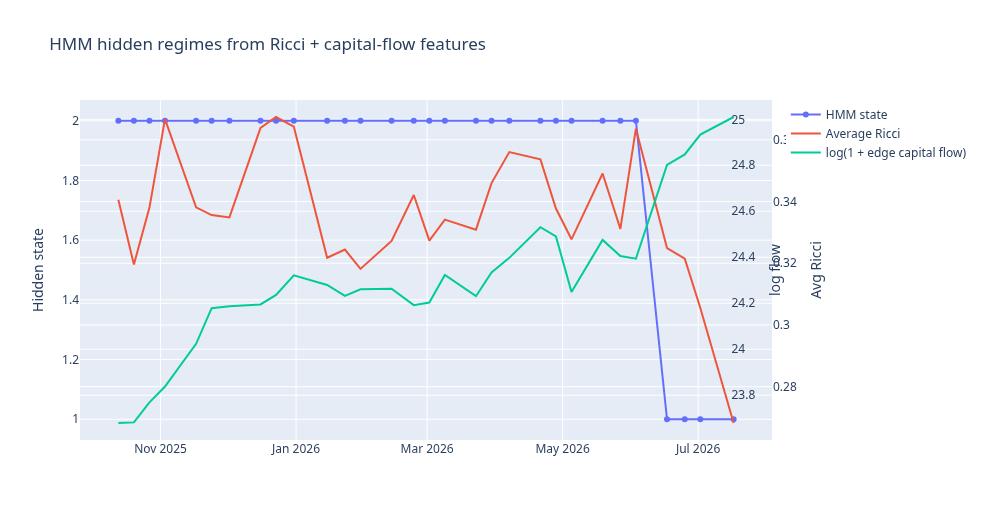

In [15]:

# compute_hmm_regimes() internally calls rolling_feature_table() in some v12
# helper versions. Temporarily provide the compatible feature table prepared
# above, then restore the original function.
# 某些 v12 helper 版本會在函式內再次呼叫 rolling_feature_table；
# 暫時提供上方已相容化的特徵表，執行後恢復原函式。

_original_rolling_feature_table = rolling_feature_table

def _compatible_rolling_feature_table(_frames):
    if _frames is frames:
        return feature_df.copy()
    table = _original_rolling_feature_table(_frames).copy()
    for target, candidates in feature_alias_candidates.items():
        if target not in table.columns:
            source = _first_existing_column(table, candidates)
            if source is not None:
                table[target] = pd.to_numeric(table[source], errors="coerce")
    if "delta2" not in table.columns:
        table["delta2"] = 0.0
    return table

try:
    rolling_feature_table = _compatible_rolling_feature_table

    hmm_df, regime_labels = compute_hmm_regimes(
        frames=frames,
        returns=returns,
        starts=starts,
        window_size=60,
        n_components=3,
        forward_days=5,
        random_state=42,
    )
finally:
    rolling_feature_table = _original_rolling_feature_table

print("Regime labels:", regime_labels)
display(hmm_df.tail())
plot_hmm_regimes(hmm_df).show()


## 15. Posterior probabilities｜後驗機率

A hard state label hides uncertainty. Posterior probabilities show how strongly the model supports each state at a frame.  
硬標籤會隱藏不確定性；後驗機率呈現模型在該影格對各狀態的支持程度。

A 52% assignment is a weak classification or transition candidate; 96% is much more decisive. These values are model confidence, not calibrated probabilities of future market outcomes.  
52% 通常是較弱分類或轉換候選；96% 則更明確。這些是模型狀態信心，不是未來市場結果的校準機率。


In [16]:
probability_columns = [
    column
    for column in hmm_df.columns
    if column.startswith("state_probability_")
]

if probability_columns:
    display(
        hmm_df[
            ["date", "hmm_state", "regime_name", "state_probability"]
            + probability_columns
        ].tail(10)
    )
else:
    print("Posterior columns are unavailable; check hmmlearn installation and frame count.")

,date,hmm_state,regime_name,state_probability,state_probability_0,state_probability_1,state_probability_2
20,2026-04-21 00:00:00,2,transition / rotation,1.0,3.795461e-69,7.894998e-74,1.0
21,2026-04-28 00:00:00,2,transition / rotation,1.0,6.860030e-71,1.363091e-75,1.0
22,2026-05-05 00:00:00,2,transition / rotation,1.0,1.476959e-71,1.806833e-69,1.0
23,2026-05-19 00:00:00,2,transition / rotation,1.0,9.313681e-69,3.201992e-47,1.0
24,2026-05-27 00:00:00,2,transition / rotation,1.0,1.556457e-69,5.311632e-31,1.0
25,2026-06-03 00:00:00,2,transition / rotation,1.0,1.840309e-56,1.244681e-15,1.0
26,2026-06-17 00:00:00,1,stress / fragmentation,1.0,6.278133e-53,1.000000e+00,0.0
27,2026-06-25 00:00:00,1,stress / fragmentation,1.0,1.354697e-47,1.000000e+00,0.0
28,2026-07-02 00:00:00,1,stress / fragmentation,1.0,4.840801e-46,1.000000e+00,0.0
29,2026-07-17 00:00:00,1,stress / fragmentation,1.0,6.648911e-44,1.000000e+00,0.0


## 16. Generate a frame-by-frame market narrative｜產生逐影格市場敘事

For a measured statistic $X$,

$$\Delta X_t=X_t-X_{t-1}.$$

The narrative translates observed changes and configured thresholds. It may say that curvature weakened or fragmentation increased, but it must not claim that these changes caused a future return.  
敘事模組翻譯觀測變化與預設門檻；它可以描述曲率轉弱或碎片化增加，但不得宣稱這些變化造成未來報酬。


In [17]:
stories = build_frame_stories(frames)
story_df = frame_story_table(stories)

display(
    story_df[
        [
            "frame",
            "date",
            "regime_name",
            "state_probability",
            "headline",
            "strongest_fragile_edge",
            "strongest_capital_edge",
        ]
    ].tail(10)
)

print("Latest narrative:\n")
print(stories[-1].narrative)

,frame,date,regime_name,state_probability,headline,strongest_fragile_edge,strongest_capital_edge
20,20,2026-04-21 00:00:00,transition / rotation,1.0,The market is rotating between network basins,ANET–QBTS (κ=0.193),"MU–NVDA (flow=10,864,215,279)"
21,21,2026-04-28 00:00:00,transition / rotation,1.0,The market is rotating between network basins,ANET–IONQ (κ=0.178),"MU–NVDA (flow=11,427,430,947)"
22,22,2026-05-05 00:00:00,transition / rotation,1.0,The market is rotating between network basins,AMD–QBTS (κ=0.124),"MU–NVDA (flow=9,965,653,328)"
23,23,2026-05-19 00:00:00,transition / rotation,1.0,The market is rotating between network basins,ANET–NVDA (κ=0.153),"MU–NVDA (flow=11,310,583,992)"
24,24,2026-05-27 00:00:00,transition / rotation,1.0,The market is rotating between network basins,QBTS–RGTI (κ=-0.017),"MU–NVDA (flow=10,305,561,339)"
25,25,2026-06-03 00:00:00,transition / rotation,1.0,The market is rotating between network basins,ANET–QBTS (κ=0.194),"MU–NVDA (flow=9,345,584,266)"
26,26,2026-06-17 00:00:00,stress / fragmentation,1.0,Fragmentation and fragile bridges dominate,IONQ–QBTS (κ=0.154),"MU–NVDA (flow=14,099,561,217)"
27,27,2026-06-25 00:00:00,stress / fragmentation,1.0,Fragmentation and fragile bridges dominate,QBTS–RGTI (κ=0.020),"MU–NVDA (flow=15,128,114,809)"
28,28,2026-07-02 00:00:00,stress / fragmentation,1.0,Fragmentation and fragile bridges dominate,QBTS–RGTI (κ=-0.106),"MU–NVDA (flow=17,065,144,498)"
29,29,2026-07-17 00:00:00,stress / fragmentation,1.0,Fragmentation and fragile bridges dominate,QBTS–RGTI (κ=0.004),"AMD–MU (flow=17,474,994,594)"


Latest narrative:

At 2026-07-17 00:00:00, the HMM classifies the rolling market graph as “stress / fragmentation” with 100% posterior confidence. Network curvature weakened (average curvature 0.306 → 0.268). Cross-network connectivity strengthened (density 0.382 → 0.491). The dominant connected market basin expanded (largest-component ratio 0.818 → 1.000). The most negative-curvature edge is QBTS–RGTI (κ=0.004); the largest capital-transport edge is AMD–MU (flow=17,474,994,594).


## 17. Animate the HMM story manifold｜製作 HMM 故事流形動畫

A stable layout is used so visual movement mainly reflects changing attributes rather than a newly randomized layout.  
使用固定佈局，使視覺變化主要反映屬性改變，而非每格重新隨機排版。

Each frame synchronizes graph geometry, HMM label, posterior confidence, measured narrative, fragile edges, and dominant capital-activity edges.  
每個影格同步呈現圖幾何、HMM 標籤、後驗信心、量測敘事、脆弱邊與主要資本活動邊。


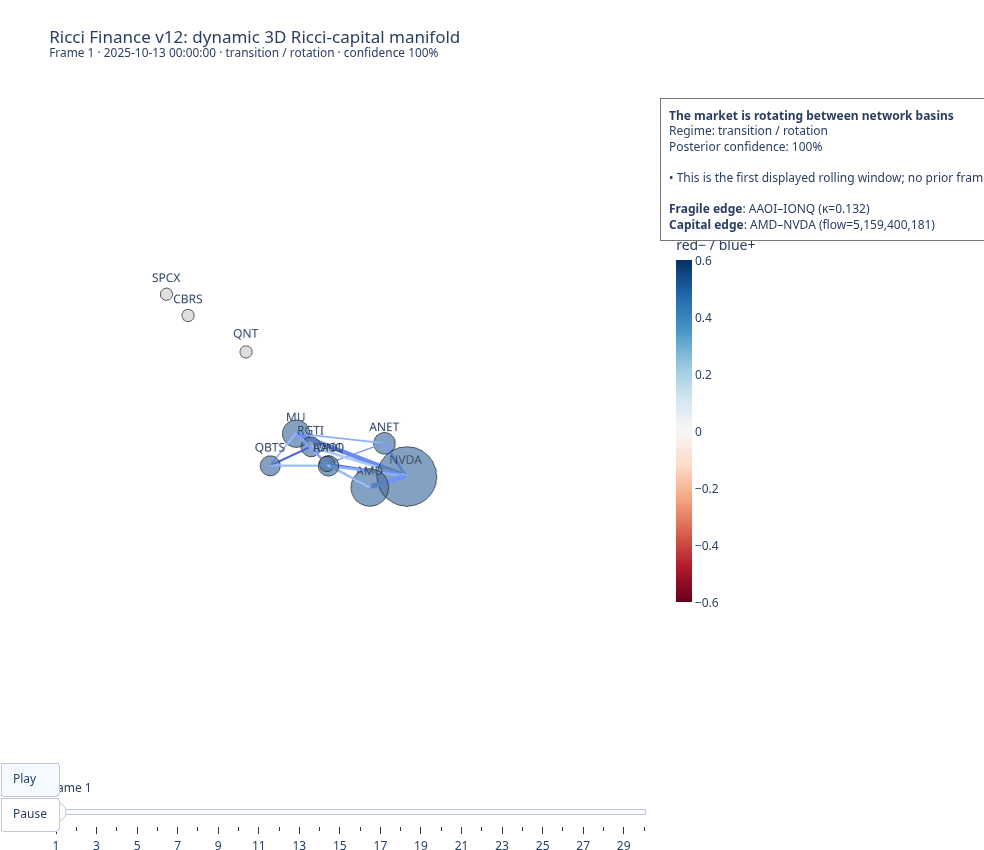

In [18]:
base_graph = build_base_graph_for_layout(
    frames,
    all_nodes=returns.columns,
)

stable_positions = compute_stable_layout_3d(
    base_graph,
    seed=42,
)

animation = build_3d_ricci_capital_animation(
    frames,
    stable_positions,
    z_mode="ricci_stress",
    stories=stories,
    frame_duration_ms=700,
)

animation.show()

## 18. Regime-coloured HMM market animation｜HMM 狀態著色市場動畫

The 3-D story-manifold animation above emphasizes network geometry. The animation below adds a complementary time-series view in which each historical price segment keeps the colour of its inferred HMM regime. The current frame background is lightly tinted by the active state, and the title reports the posterior confidence.  
上方的 3-D 故事流形動畫著重網路幾何；下方動畫提供互補的時間序列視圖。每段歷史價格線保留其 HMM 推論狀態顏色，當前影格背景以目前狀態淡色顯示，標題則呈現後驗信心。

> **Important:** state IDs such as 0, 1, and 2 have no inherent bull/bear meaning. Colours follow `regime_name`, which is assigned only after examining the complete state profile. Posterior probability expresses model confidence in the latent-state assignment—not the probability of a future gain or loss.  
> **重要：** 狀態編號 0、1、2 本身沒有多頭或空頭意義。顏色依據事後解讀的 `regime_name`；後驗機率表示模型對潛在狀態分類的信心，並非未來上漲或下跌的機率。

Suggested semantic colours｜建議語意顏色：

- Bull / expansion｜多頭／擴張：green｜綠色
- Bear / contraction｜空頭／收縮：red｜紅色
- Rotation / transition｜輪動／轉換：blue｜藍色
- Stress / crisis｜壓力／危機：orange or purple｜橘色或紫色
- Sideways / neutral｜盤整／中性：gray｜灰色


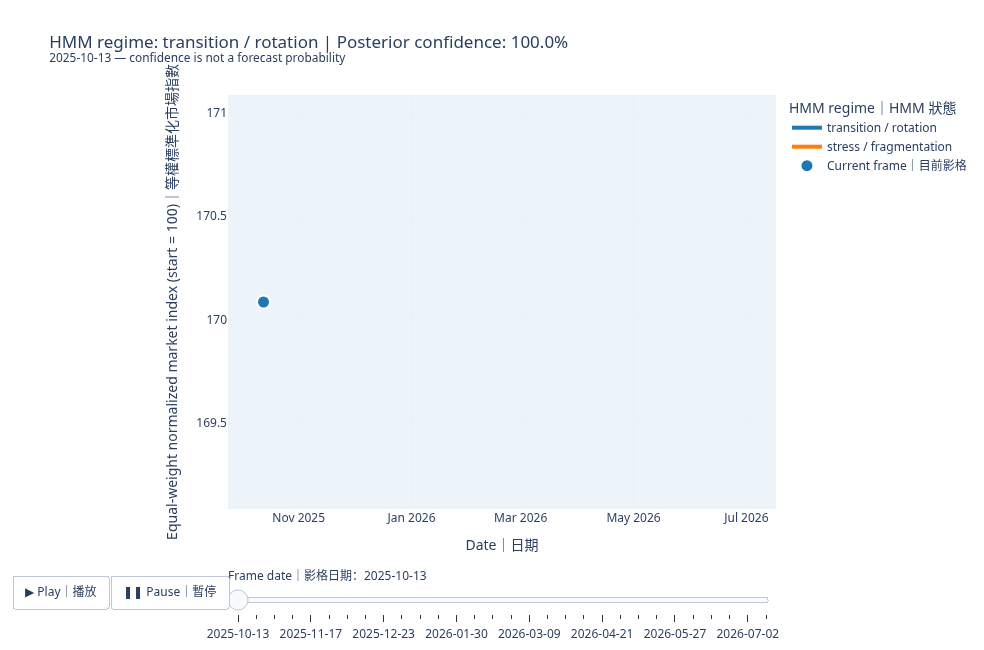

Regime colour mapping｜狀態顏色對照：
  transition / rotation: #1f77b4
  stress / fragmentation: #ff7f0e


In [19]:

import plotly.graph_objects as go
from plotly.colors import qualitative
from pandas.api.types import is_datetime64_any_dtype

# -------------------------------------------------------------------
# Prepare an equal-weight market index and align it with HMM frame dates.
# 建立等權市場指數，並與 HMM 影格日期對齊。
# -------------------------------------------------------------------
if "close" not in globals() or "hmm_df" not in globals():
    raise NameError("Run the market-data and HMM cells before this animation cell.")

price_panel = close.copy().sort_index().ffill()
price_panel = price_panel.loc[:, price_panel.notna().sum() > 1]

if price_panel.empty:
    raise ValueError("No usable closing-price columns are available.")

normalized_prices = price_panel.div(price_panel.iloc[0]).mul(100.0)
market_index = normalized_prices.mean(axis=1, skipna=True).rename("market_index")

regime_animation_df = hmm_df.copy()
regime_animation_df["date"] = (
    pd.to_datetime(regime_animation_df["date"], errors="coerce")
    .astype("datetime64[ns]")
)
regime_animation_df = (
    regime_animation_df
    .dropna(subset=["date"])
    .sort_values("date")
    .drop_duplicates("date", keep="last")
)

market_index_df = market_index.rename_axis("date").reset_index()
market_index_df["date"] = (
    pd.to_datetime(market_index_df["date"], errors="coerce")
    .astype("datetime64[ns]")
)
market_index_df = (
    market_index_df
    .dropna(subset=["date"])
    .sort_values("date")
    .drop_duplicates("date", keep="last")
)

# Use the latest available market observation at or before each HMM frame date.
# 每個 HMM 日期使用當日或之前最近一筆市場指數。
# Remove a stale market_index column before re-running this cell.
# 重新執行本儲存格前，先移除可能殘留的 market_index 欄位。
regime_animation_df = regime_animation_df.drop(
    columns=["market_index"], errors="ignore"
)

# pandas.merge_asof requires exactly matching datetime units.
# pandas.merge_asof 要求左右鍵具有完全相同的 datetime 單位。
regime_animation_df["date"] = regime_animation_df["date"].astype("datetime64[ns]")
market_index_df["date"] = market_index_df["date"].astype("datetime64[ns]")

regime_animation_df = pd.merge_asof(
    regime_animation_df.sort_values("date"),
    market_index_df.sort_values("date"),
    on="date",
    direction="backward",
).dropna(subset=["market_index", "regime_name"])

regime_animation_df["regime_name"] = regime_animation_df["regime_name"].astype(str)
regime_animation_df["state_probability"] = pd.to_numeric(
    regime_animation_df["state_probability"], errors="coerce"
).fillna(0.0).clip(0.0, 1.0)

if len(regime_animation_df) < 2:
    raise ValueError("At least two aligned HMM frames are required for animation.")

# -------------------------------------------------------------------
# Assign semantic colours from regime names. Unknown names receive
# deterministic fallback colours.
# 依狀態名稱配置語意顏色；未知名稱使用固定備援色盤。
# -------------------------------------------------------------------
semantic_colours = {
    "bull": "#2ca02c",
    "expansion": "#2ca02c",
    "growth": "#2ca02c",
    "bear": "#d62728",
    "contraction": "#d62728",
    "decline": "#d62728",
    "stress": "#ff7f0e",
    "crisis": "#9467bd",
    "fragile": "#9467bd",
    "rotation": "#1f77b4",
    "transition": "#1f77b4",
    "sideways": "#7f7f7f",
    "neutral": "#7f7f7f",
    "stable": "#17becf",
}

fallback_palette = qualitative.Safe + qualitative.Set2
unique_regimes = list(dict.fromkeys(regime_animation_df["regime_name"]))

def choose_regime_colour(name, fallback_index):
    lower_name = name.lower()
    for keyword, colour in semantic_colours.items():
        if keyword in lower_name:
            return colour
    return fallback_palette[fallback_index % len(fallback_palette)]

regime_colours = {
    name: choose_regime_colour(name, i)
    for i, name in enumerate(unique_regimes)
}

# Convert #RRGGBB into a transparent rgba background.
def hex_to_rgba(hex_colour, alpha=0.08):
    value = hex_colour.lstrip("#")
    if len(value) != 6:
        return f"rgba(127,127,127,{alpha})"
    r, g, b = (int(value[i:i+2], 16) for i in (0, 2, 4))
    return f"rgba({r},{g},{b},{alpha})"

# -------------------------------------------------------------------
# Build one persistent trace per regime. Historical points retain their
# original state colour. NaNs deliberately create gaps between regimes.
# 為每個狀態建立固定軌跡；歷史點保留原狀態顏色，NaN 用來切斷狀態段落。
# -------------------------------------------------------------------
dates = regime_animation_df["date"].tolist()
values = regime_animation_df["market_index"].astype(float).tolist()
regimes = regime_animation_df["regime_name"].tolist()
probabilities = regime_animation_df["state_probability"].astype(float).tolist()

def regime_trace_y(regime, end_index):
    y = [None] * len(values)
    for k in range(end_index + 1):
        if regimes[k] == regime:
            y[k] = values[k]
            # Include the previous point so the coloured segment is connected.
            if k > 0 and y[k - 1] is None:
                y[k - 1] = values[k - 1]
    return y

initial_traces = []
for regime in unique_regimes:
    initial_traces.append(
        go.Scatter(
            x=dates,
            y=regime_trace_y(regime, 0),
            mode="lines",
            name=regime,
            line=dict(color=regime_colours[regime], width=4),
            connectgaps=False,
            hovertemplate=(
                "%{x|%Y-%m-%d}<br>"
                "Index: %{y:.2f}<br>"
                f"Regime: {regime}<extra></extra>"
            ),
        )
    )

# Current-frame marker
initial_traces.append(
    go.Scatter(
        x=[dates[0]],
        y=[values[0]],
        mode="markers",
        name="Current frame｜目前影格",
        marker=dict(
            size=13,
            color=regime_colours[regimes[0]],
            line=dict(color="white", width=2),
        ),
        hovertemplate=(
            "%{x|%Y-%m-%d}<br>"
            "Index: %{y:.2f}<extra></extra>"
        ),
    )
)

frames_plotly = []
for i in range(len(regime_animation_df)):
    current_regime = regimes[i]
    current_colour = regime_colours[current_regime]
    frame_data = []

    for regime in unique_regimes:
        frame_data.append(
            go.Scatter(
                x=dates,
                y=regime_trace_y(regime, i),
            )
        )

    frame_data.append(
        go.Scatter(
            x=[dates[i]],
            y=[values[i]],
            marker=dict(
                size=13,
                color=current_colour,
                line=dict(color="white", width=2),
            ),
        )
    )

    frames_plotly.append(
        go.Frame(
            name=str(i),
            data=frame_data,
            layout=go.Layout(
                plot_bgcolor=hex_to_rgba(current_colour, 0.08),
                title=dict(
                    text=(
                        f"HMM regime: {current_regime} | "
                        f"Posterior confidence: {probabilities[i]:.1%}<br>"
                        f"<sup>{dates[i]:%Y-%m-%d} — "
                        "confidence is not a forecast probability</sup>"
                    )
                ),
                shapes=[
                    dict(
                        type="line",
                        x0=dates[i],
                        x1=dates[i],
                        y0=0,
                        y1=1,
                        yref="paper",
                        line=dict(color=current_colour, width=2, dash="dot"),
                    )
                ],
            ),
        )
    )

fig_hmm_regime_animation = go.Figure(
    data=initial_traces,
    frames=frames_plotly,
)

slider_steps = [
    {
        "args": [
            [str(i)],
            {
                "frame": {"duration": 0, "redraw": True},
                "mode": "immediate",
                "transition": {"duration": 0},
            },
        ],
        "label": dates[i].strftime("%Y-%m-%d"),
        "method": "animate",
    }
    for i in range(len(dates))
]

fig_hmm_regime_animation.update_layout(
    title=(
        f"HMM regime: {regimes[0]} | "
        f"Posterior confidence: {probabilities[0]:.1%}<br>"
        f"<sup>{dates[0]:%Y-%m-%d} — confidence is not a forecast probability</sup>"
    ),
    xaxis_title="Date｜日期",
    yaxis_title="Equal-weight normalized market index (start = 100)｜等權標準化市場指數",
    hovermode="x unified",
    legend_title="HMM regime｜HMM 狀態",
    template="plotly_white",
    height=650,
    margin=dict(l=70, r=35, t=95, b=120),
    plot_bgcolor=hex_to_rgba(regime_colours[regimes[0]], 0.08),
    updatemenus=[
        {
            "type": "buttons",
            "direction": "left",
            "x": 0.0,
            "y": -0.16,
            "showactive": False,
            "buttons": [
                {
                    "label": "▶ Play｜播放",
                    "method": "animate",
                    "args": [
                        None,
                        {
                            "frame": {"duration": 500, "redraw": True},
                            "fromcurrent": True,
                            "transition": {"duration": 150},
                        },
                    ],
                },
                {
                    "label": "❚❚ Pause｜暫停",
                    "method": "animate",
                    "args": [
                        [None],
                        {
                            "frame": {"duration": 0, "redraw": False},
                            "mode": "immediate",
                            "transition": {"duration": 0},
                        },
                    ],
                },
            ],
        }
    ],
    sliders=[
        {
            "active": 0,
            "currentvalue": {
                "prefix": "Frame date｜影格日期：",
                "visible": True,
            },
            "pad": {"t": 55},
            "steps": slider_steps,
        }
    ],
)

fig_hmm_regime_animation.show()

print("Regime colour mapping｜狀態顏色對照：")
for regime, colour in regime_colours.items():
    print(f"  {regime}: {colour}")


### Reading the animation｜動畫判讀

1. A colour change marks an inferred regime transition; it does not by itself prove an economic turning point.  
   顏色改變代表模型推論的狀態轉換，不單獨證明經濟轉折。
2. Low `state_probability` near a colour boundary indicates an uncertain transition.  
   顏色交界附近若 `state_probability` 偏低，表示轉換仍不確定。
3. Compare this time-series animation with the 3-D manifold animation: the former shows **when** the state changes, while the latter helps explain **which geometric structures** accompany the change.  
   將此時間序列動畫與 3-D 流形動畫對照：前者顯示狀態在**何時**改變，後者協助觀察狀態改變伴隨哪些**幾何結構**。


## 19. Selected-frame analysis｜選定影格分析

The Streamlit **Selected frame** control chooses one rolling window for detailed inspection. This cell reproduces that behavior.  
Streamlit 的 **Selected frame** 控制項選擇一個滾動視窗深入檢查；本格重現該行為。


In [ ]:
SELECTED_FRAME = len(frames) - 1
selected = frames[SELECTED_FRAME]
selected_story = stories[SELECTED_FRAME]

print("Frame:", SELECTED_FRAME + 1)
print("Date:", selected_story.date)
print("Regime:", selected_story.regime_name)
print("Confidence:", selected_story.state_probability)
print("Headline:", selected_story.headline)
print("Narrative:", selected_story.narrative)

display(summarize_edges(selected.G))
display(surgery_risk_direction_table(selected.G).head(10))

## 20. Research interpretation and limitations｜研究解釋與限制

1. Correlation is not causation.｜相關不等於因果。
2. Capital flow is a proxy, not measured fund transfer.｜資本流是代理量，不是實際基金流向。
3. HMM labels are sample- and initialization-dependent.｜HMM 標籤依樣本與初始化而變。
4. Curvature describes graph geometry, not expected return.｜曲率描述圖幾何，不是預期報酬。
5. Ricci flow is regularization, not forecasting.｜Ricci flow 是正則化，不是預測。
6. Narrative output depends on thresholds in `story.py`.｜敘事輸出依賴 `story.py` 的門檻。
7. Tickers, windows, missing data, and graph rules can materially change results.｜代號、視窗、缺失資料與建圖規則會顯著改變結果。
8. HMM in-sample probabilities are not evidence of predictive power.｜樣本內 HMM 機率不代表具有預測力。
9. Use walk-forward validation and avoid look-ahead leakage.｜應使用 walk-forward 驗證並避免前視偏誤。
10. “Manifold” is a modeling metaphor unless manifold assumptions are separately established.｜除非另行證明流形假設，否則「流形」主要是建模比喻。


## 21. Self-exercises｜自我練習

1. Change the window from 60 to 20 days; compare regime and edge stability.｜將視窗由 60 改為 20 日，比較狀態與邊穩定度。
2. Compare `threshold`, `knn`, and `knn+bridges`.｜比較三種建圖模式。
3. Set `capital_alpha=0`; identify the largest curvature changes.｜將 `capital_alpha=0`，找出曲率變化最大的邊。
4. Increase HMM states from 3 to 4; test stability across random seeds.｜將 HMM 狀態由 3 增至 4，並跨隨機種子檢驗穩定性。
5. Inspect low-confidence frames and their graph geometry.｜檢查低信心影格及其圖幾何。
6. Compare the most negative-curvature edge with the largest activity-proxy edge.｜比較最負曲率邊與最大活動代理量邊。
7. Design a walk-forward test for out-of-sample predictive information.｜設計 walk-forward 測試以檢驗樣本外預測資訊。
8. Document failures caused by IPO dates, missing prices, and sparse overlap.｜記錄 IPO 日期、缺價與共同樣本不足造成的失敗。

### Suggested research modules｜建議研究模組

- directed lead–lag graphs｜有向領先—落後圖
- persistent community matching｜持續性社群匹配
- walk-forward HMM validation｜HMM walk-forward 驗證
- probabilistic feature forecasting｜機率式特徵預測
- reproducible HTML/MP4 export｜可重現的 HTML／MP4 匯出


---

**End of notebook｜筆記本結束**
